# Building Concentric circle with the use of ReLU activation function and trainnig it using Binary Cross-Entropy Loss and the Adam optimizer

Epoch 0 | Loss: 0.6937 | Accuracy: 50.00%
Epoch 100 | Loss: 0.2016 | Accuracy: 99.90%
Epoch 200 | Loss: 0.0329 | Accuracy: 100.00%
Epoch 300 | Loss: 0.0131 | Accuracy: 100.00%
Epoch 400 | Loss: 0.0073 | Accuracy: 100.00%


/var/folders/v0/6kn69j2161z785vv9jl965xw0000gn/T/ipykernel_65047/2188828228.py:76: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))


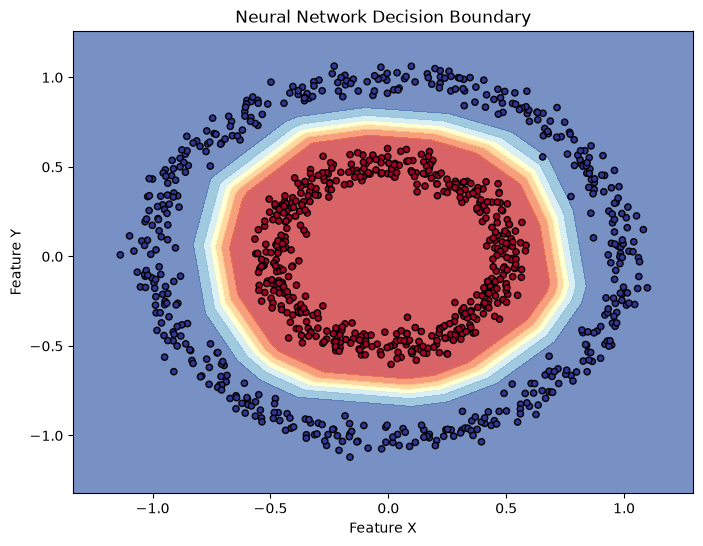

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# --- DATA GENERATION  ---
def make_circles(n_points=1000, noise=0.05, radius_inner=0.5, radius_outer=1.0):
    n = n_points // 2
    theta = torch.linspace(0, 2 * np.pi, n)
    x0 = torch.stack([radius_inner * torch.cos(theta), radius_inner * torch.sin(theta)], dim=1)
    x0 += torch.randn_like(x0) * noise
    x1 = torch.stack([radius_outer * torch.cos(theta), radius_outer * torch.sin(theta)], dim=1)
    x1 += torch.randn_like(x1) * noise
    X = torch.cat([x0, x1], dim=0)
    y = torch.cat([torch.zeros(n), torch.ones(n)]).float() # Converted to float for BCEWithLogitsLoss
    return X, y

X, y = make_circles()

# --- NEURAL NETWORK MODEL DEFINITION ---
class CircleClassifier(nn.Module):
    def __init__(self):
        super(CircleClassifier, self).__init__()
        # Input layer to Hidden Layer: 2 inputs (X, Y coordinates) -> 16 hidden neurons
        self.dense1 = nn.Linear(in_features=2, out_features=16)
        # Activation Function
        self.relu = nn.ReLU()
        # Hidden Layer to Output Layer: 16 hidden neurons -> 1 output prediction
        self.dense2 = nn.Linear(in_features=16, out_features=1)
        
    def forward(self, x):
        # Forward pass execution
        x = self.dense1(x)
        x = self.relu(x)
        x = self.dense2(x)
        return x

# Instantiate model, loss, and optimizer
model = CircleClassifier()
criterion = nn.BCEWithLogitsLoss() # Combines Sigmoid layer and Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# --- TRAINING LOOP (Forward, Loss, Gradient, Optimize) ---
epochs = 500
for epoch in range(epochs):
    model.train()
    
    # Forward Pass
    y_logits = model(X).squeeze() 
    
    # Loss Calculation
    loss = criterion(y_logits, y)
    
    # Gradients Set to Zero
    optimizer.zero_grad()
    
    # Backward Pass (Gradient calculation via backpropagation)
    loss.backward()
    
    # Optimizer Step (Update model weights)
    optimizer.step()
    
    # Print progress every 100 epochs
    if epoch % 100 == 0:
        # Calculate accuracy
        y_pred = torch.round(torch.sigmoid(y_logits))
        acc = (y_pred == y).sum().item() / len(y) * 100
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Accuracy: {acc:.2f}%")

# --- DECISION BOUNDARY PLOT ---
def plot_decision_boundary(model, X, y):
    # Setting up a grid to evaluate the model over the entire coordinate space
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    
    # Converting grid points to PyTorch tensor and predict
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    model.eval()
    with torch.inference_mode():
        preds = torch.sigmoid(model(grid_points)).reshape(xx.shape).numpy()
    
    # Plotting the background decision contour and the dataset points
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=20)
    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Feature X")
    plt.ylabel("Feature Y")
    plt.show()

plot_decision_boundary(model, X, y)